In [73]:
import sys
sys.path.append("../src")

In [74]:
import numpy as np
import matplotlib.pyplot as plt

In [75]:
def newton_fractal(func, dfunc, xlim=(-1.5, 1.5), ylim=(-1.5, 1.5),
                   resolution=500, max_iter=50, tol=1e-6):
    """
    roots : ndarray of complex
        Array of discovered root values.
    root_index : ndarray of shape (resolution, resolution)
        Integer index mapping each pixel to a root (0..len(roots)-1).
    iters : ndarray of shape (resolution, resolution)
        Number of iterations taken to converge (max_iter if not converged).
    img : ndarray
        Float image array (root index + normalized iteration) suitable for imshow.
    """
    re = np.linspace(xlim[0], xlim[1], resolution)
    im = np.linspace(ylim[0], ylim[1], resolution)
    Re, Im = np.meshgrid(re, im[::-1])  # flip im so image y axis is conventional
    z = Re + 1j * Im
    z = z.astype(np.complex128)
    
    # iteration trackers
    iters = np.full(z.shape, max_iter, dtype=int)
    converged = np.zeros(z.shape, dtype=bool)
    
    # Newton iterations (vectorized)
    for k in range(max_iter):
        # avoid division by zero: add tiny epsilon where derivative is zero
        derivative = dfunc(z) + 1e-12 # avoid div by 0
        # Newton step
        z_next = z - func(z) / derivative
        # check convergence using function value
        just_converged = (~converged) & (np.abs(func(z_next)) < tol)
        iters[just_converged] = k
        converged = converged | just_converged
        z = z_next
    
    # After iterations, group final z into distinct roots
    flat_z = z.ravel()
    flat_converged = converged.ravel()
    root_list = []
    root_index_flat = np.full(flat_z.shape, -1, dtype=int)
    root_tol = 1e-3  # tolerance for considering two z values the same root
    for i, val in enumerate(flat_z):
        assigned = False
        if not flat_converged[i]:
            root_index_flat[i] = -1
        else:
            for r_idx, r in enumerate(root_list):
                if np.abs(val - r) < root_tol:
                    root_index_flat[i] = r_idx
                    assigned = True
                    break
            if not assigned:
                root_list.append(val)
                root_index_flat[i] = len(root_list) - 1
    roots = np.array(root_list)
    root_index = root_index_flat.reshape(z.shape)
    return roots, root_index, iters

In [ ]:
def e_surf(k_hat, qs, ms, sum_q_0, k):
    k = k_hat * np.expand_dims(k, axis = -1)
    return np.sum([
        np.sqrt(np.sum((k + q)**2, axis = -1) + m**2) for q, m in zip(qs, ms)
        ], axis = 0) + sum_q_0


def d_e_surf(k_hat, qs, ms, k):
    k = k_hat * np.expand_dims(k, axis=-1)
    return np.sum([
        np.sum((k+q)*k_hat, axis = -1) / \
            np.sqrt(np.sum((k+q)**2, axis = -1) + m**2) for q, m in zip(qs, ms)
    ], axis = 0)

In [77]:
RES = 300

k_hat = np.array([0, 0, 1])
qs = [np.array([-2, 0, 0]),np.array([2,0,1]), np.array([0,2,-1])]
ms = [0.1,0.11, 0.2]

# Generate fractal
roots, root_index, iters = newton_fractal(
    lambda k: e_surf(k_hat, qs, ms, -7, k),
    lambda k: d_e_surf(k_hat, qs, ms, k),
    xlim=(-10, 10),
    ylim=(-10, 10),
    resolution=RES,
    max_iter=100,
    tol=1e-12,
)

print("Discovered roots (approx):")
for i, r in enumerate(roots):
    print(f"root {i}: {r:.6f}")

Discovered roots (approx):
root 0: -0.931186+0.000000j
root 1: 0.929391-0.000000j


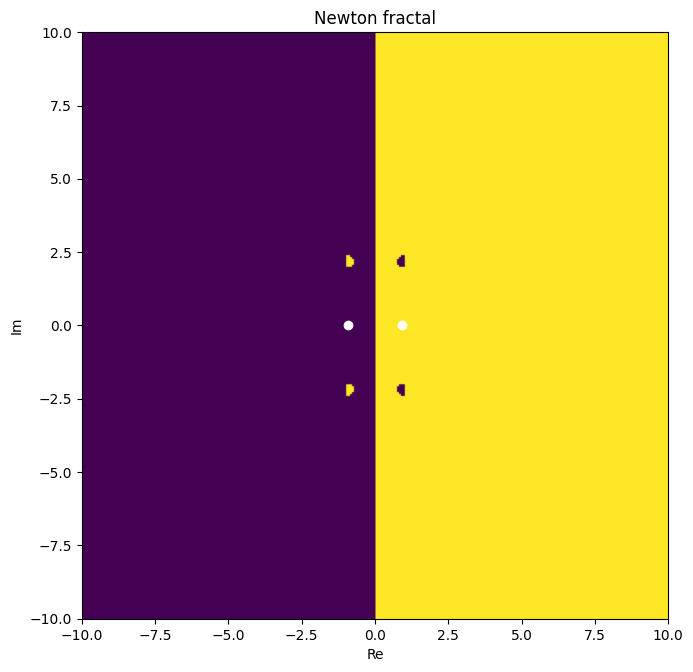

In [78]:
from matplotlib.colors import hsv_to_rgb
colors = np.array([[255, 0, 0], [0, 255, 0]])


x = np.linspace(-10, 10, RES)
y = np.linspace(-10, 10, RES)
X, Y = np.meshgrid(x, y)
xs = X + 1j*Y
e_surface = 1/e_surf(k_hat, qs, ms, 0, xs)
# magnitude → brightness
mag = np.abs(e_surface)
#mag = mag / mag.max()    # normalize to [0,1]

# phase → hue
phase = np.angle(e_surface)
phase = (phase + np.pi) / (2*np.pi)   # map [-pi,pi] to [0,1]

# HSV image

newton_fractal_factor = (root_index+1)/2
hsv = np.zeros(e_surface.shape + (3,))
hsv[..., 0] = phase
hsv[..., 1] = 1
hsv[..., 2] = ((mag % 1)+1)/2


img = hsv_to_rgb(hsv)

plt.figure(figsize=(7, 7))
plt.imshow(
    newton_fractal_factor, extent=(-10, 10, -10, 10), origin="lower"
)
plt.xlabel("Re")
plt.ylabel("Im")
plt.scatter(roots.real, roots.imag, c='white')
plt.title("Newton fractal")
plt.tight_layout()
plt.show()